In [ ]:
# Cell 1: Import libraries

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import joblib

pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 100)

DATA_PATH = Path("../data/diabetic_data.csv")  
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42

In [2]:
# Cell 2: Load the dataset

df_raw = pd.read_csv(DATA_PATH)

print("Dataset shape:", df_raw.shape)
display(df_raw.head())
display(df_raw.tail())

FileNotFoundError: [Errno 2] No such file or directory: 'diabetic_data.csv'

In [ ]:
# Cell 3: Basic structure

print("Rows:", df_raw.shape[0])
print("Columns:", df_raw.shape[1])

print("\nData types:")
display(df_raw.dtypes.value_counts())

print("\nColumn names:")
print(df_raw.columns.tolist())

print("\nDataset information:")
df_raw.info()

Rows: 101766
Columns: 50

Data types:


object    37
int64     13
Name: count, dtype: int64


Column names:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non

In [ ]:
# Cell 4: Replace question marks with missing values

# In this dataset, '?' is used in several columns to represent missing/unknown values.
df = df_raw.replace("?", np.nan).copy()

missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (df.isna().mean() * 100).round(2),
    "data_type": df.dtypes.astype(str)
}).sort_values("missing_count", ascending=False)

display(missing_summary[missing_summary["missing_count"] > 0])

missing_summary.to_csv(OUTPUT_DIR / "missing_values_summary.csv")

,missing_count,missing_percentage,data_type
weight,98569,96.86,object
max_glu_serum,96420,94.75,object
A1Cresult,84748,83.28,object
medical_specialty,49949,49.08,object
payer_code,40256,39.56,object
race,2273,2.23,object
diag_3,1423,1.40,object
diag_2,358,0.35,object
diag_1,21,0.02,object


,count,percentage
readmitted,,
NO,54864,53.91
>30,35545,34.93
<30,11357,11.16


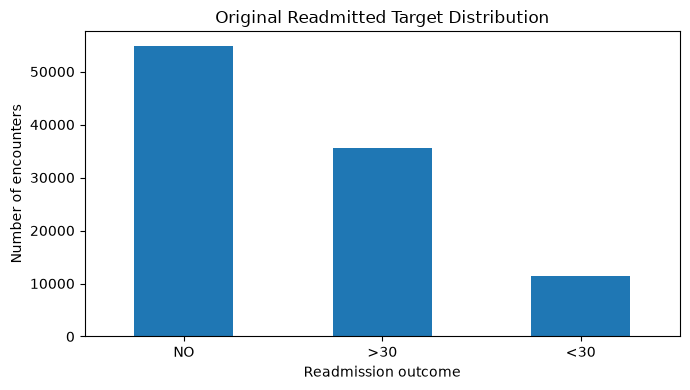

In [ ]:
# Cell 5: Target variable distribution

target_counts = df["readmitted"].value_counts(dropna=False)
target_percentages = (df["readmitted"].value_counts(normalize=True, dropna=False) * 100).round(2)

target_summary = pd.DataFrame({
    "count": target_counts,
    "percentage": target_percentages
})

display(target_summary)

ax = target_counts.reindex(["NO", ">30", "<30"]).plot(
    kind="bar",
    figsize=(7, 4),
    title="Original Readmitted Target Distribution"
)
ax.set_xlabel("Readmission outcome")
ax.set_ylabel("Number of encounters")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

target_summary.to_csv(OUTPUT_DIR / "target_distribution.csv")

In [ ]:
# Cell 6: Confirm the three-class target

expected_classes = {"NO", ">30", "<30"}
actual_classes = set(df["readmitted"].dropna().unique())

print("Actual target classes:", actual_classes)
print("Expected classes:", expected_classes)
print("All expected classes present:", expected_classes.issubset(actual_classes))

Actual target classes: {'>30', '<30', 'NO'}
Expected classes: {'>30', '<30', 'NO'}
All expected classes present: True


In [ ]:
# Cell 7: Identifier analysis

identifier_columns = ["encounter_id", "patient_nbr"]

identifier_summary = pd.DataFrame({
    "unique_values": [df[col].nunique(dropna=False) for col in identifier_columns],
    "duplicate_values": [df[col].duplicated().sum() for col in identifier_columns]
}, index=identifier_columns)

display(identifier_summary)

print("Exact duplicate rows:", df.duplicated().sum())
print("Unique patients:", df["patient_nbr"].nunique())
print("Patients with more than one encounter:",
      (df["patient_nbr"].value_counts() > 1).sum())

patient_encounter_counts = df["patient_nbr"].value_counts()
display(patient_encounter_counts.describe())

,unique_values,duplicate_values
encounter_id,101766,0
patient_nbr,71518,30248


Exact duplicate rows: 0
Unique patients: 71518
Patients with more than one encounter: 16773


count    71518.000000
mean         1.422942
std          1.090740
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         40.000000
Name: count, dtype: float64

In [ ]:
# Cell 8: Duplicate investigation

exact_duplicate_rows = df.duplicated().sum()
duplicate_encounter_ids = df["encounter_id"].duplicated().sum()

print("Exact duplicate rows:", exact_duplicate_rows)
print("Repeated encounter_id values:", duplicate_encounter_ids)

# Repeated patient_nbr values are not automatically duplicates.
# They may represent separate hospital encounters.
repeated_patient_records = df[df["patient_nbr"].duplicated(keep=False)].sort_values("patient_nbr")
display(repeated_patient_records[["patient_nbr", "encounter_id", "readmitted"]].head(20))

Exact duplicate rows: 0
Repeated encounter_id values: 0


,patient_nbr,encounter_id,readmitted
4780,135,26264286,>30
4267,135,24437208,<30
5953,1152,30180318,>30
23623,1152,80742510,>30
14180,1152,55533660,>30
24642,1152,83281464,NO
1164,1152,8380170,>30
19914,1314,70601076,NO
19765,1314,70190028,<30
15848,1314,60254142,>30


In [ ]:
# Cell 19: Feature engineering

# These features are derived only from information recorded in the encounter.
# Review their suitability with the lecturer and document the reason.

df_work["total_previous_visits"] = (
    df_work["number_outpatient"].fillna(0)
    + df_work["number_emergency"].fillna(0)
    + df_work["number_inpatient"].fillna(0)
)

df_work["has_previous_inpatient_visit"] = (
    df_work["number_inpatient"].fillna(0) > 0
).astype(int)

df_work["total_procedures"] = (
    df_work["num_lab_procedures"].fillna(0)
    + df_work["num_procedures"].fillna(0)
)

display(df_work[
    [
        "number_outpatient",
        "number_emergency",
        "number_inpatient",
        "total_previous_visits",
        "has_previous_inpatient_visit",
        "num_lab_procedures",
        "num_procedures",
        "total_procedures"
    ]
].head())

,number_outpatient,number_emergency,number_inpatient,total_previous_visits,has_previous_inpatient_visit,num_lab_procedures,num_procedures,total_procedures
0,0,0,0,0,0,41,0,41
1,0,0,0,0,0,59,0,59
2,2,0,1,3,1,11,5,16
3,0,0,0,0,0,44,1,45
4,0,0,0,0,0,51,0,51


In [ ]:
# Cell 20: Optional age ordinal feature

# Age is stored as intervals such as [50-60).
# This creates an approximate midpoint feature while retaining the original age category.
# The midpoint is an approximation and should be explained in the report.

age_midpoints = {
    "[0-10)": 5,
    "[10-20)": 15,
    "[20-30)": 25,
    "[30-40)": 35,
    "[40-50)": 45,
    "[50-60)": 55,
    "[60-70)": 65,
    "[70-80)": 75,
    "[80-90)": 85,
    "[90-100)": 95
}

df_work["age_midpoint"] = df_work["age"].map(age_midpoints)

display(df_work[["age", "age_midpoint"]].head())

,age,age_midpoint
0,[0-10),5
1,[10-20),15
2,[20-30),25
3,[30-40),35
4,[40-50),45


In [ ]:
# Cell 21: Review high-missingness columns

missing_percentages = df_work.isna().mean() * 100

high_missingness = (
    missing_percentages[missing_percentages >= 40]
    .sort_values(ascending=False)
    .to_frame("missing_percentage")
)

display(high_missingness)

# Do not automatically delete all high-missingness columns.
# Decide using:
# 1. Missingness level
# 2. Feature meaning
# 3. Predictive usefulness
# 4. Whether missingness itself may contain information

,missing_percentage
weight,96.858479
max_glu_serum,94.746772
A1Cresult,83.277322
medical_specialty,49.082208


In [ ]:
# Cell 22: Define columns to exclude from model features

# Identifiers are excluded from model input.
# patient_nbr is retained separately for grouped splitting.
# readmitted is the target and must not be used as an input feature.

ID_COLUMNS = ["encounter_id", "patient_nbr"]
TARGET_COLUMN = "readmitted"

# weight has extremely high missingness in this dataset.
# This is a proposed baseline decision and should be justified in the report.
PROPOSED_DROP_COLUMNS = ["weight"]

# Discharge disposition requires a leakage and cohort review.
# It is not automatically dropped here because it may be available at discharge.
# Investigate death/hospice/transfer categories separately.

model_df = df_work.drop(
    columns=[col for col in PROPOSED_DROP_COLUMNS if col in df_work.columns]
).copy()

print("Shape after proposed column removal:", model_df.shape)

Shape after proposed column removal: (101766, 53)


In [ ]:
# Cell 23: Check discharge disposition categories

# Review these categories before finalizing the feature list.
# Some categories may represent death, hospice, or transfer and may affect
# whether a later readmission is meaningful.

disposition_counts = model_df["discharge_disposition_id"].value_counts(dropna=False).sort_index()
display(disposition_counts)

# Use the dataset documentation / data dictionary and lecturer guidance
# to map and investigate the meaning of the codes before making a final decision.

discharge_disposition_id
1     60234
2      2128
3     13954
4       815
5      1184
6     12902
7       623
8       108
9        21
10        6
11     1642
12        3
13      399
14      372
15       63
16       11
17       14
18     3691
19        8
20        2
22     1993
23      412
24       48
25      989
27        5
28      139
Name: count, dtype: int64

In [ ]:
# Cell 24: Patient-level train/test split

# Because one patient can have multiple encounters, use patient_nbr as a grouping
# variable so that the same patient is not placed in both train and test sets.

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=RANDOM_STATE
)

train_indices, test_indices = next(
    splitter.split(
        model_df,
        y=model_df[TARGET_COLUMN],
        groups=model_df["patient_nbr"]
    )
)

train_df = model_df.iloc[train_indices].copy()
test_df = model_df.iloc[test_indices].copy()

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

print("Patients in both sets:",
      len(set(train_df["patient_nbr"]).intersection(set(test_df["patient_nbr"]))))

print("\nTraining target distribution:")
display(train_df[TARGET_COLUMN].value_counts(normalize=True).mul(100).round(2))

print("\nTesting target distribution:")
display(test_df[TARGET_COLUMN].value_counts(normalize=True).mul(100).round(2))

Training shape: (81613, 53)
Testing shape: (20153, 53)
Patients in both sets: 0

Training target distribution:


readmitted
NO     53.73
>30    34.99
<30    11.28
Name: proportion, dtype: float64


Testing target distribution:


readmitted
NO     54.65
>30    34.67
<30    10.67
Name: proportion, dtype: float64

In [ ]:
# Cell 25: Separate identifiers, target, and model features

# Keep patient_nbr only for checking the grouped split.
# Do not include encounter_id or patient_nbr as model predictors.

group_train = train_df["patient_nbr"].copy()
group_test = test_df["patient_nbr"].copy()

y_train = train_df[TARGET_COLUMN].copy()
y_test = test_df[TARGET_COLUMN].copy()

X_train = train_df.drop(columns=[TARGET_COLUMN] + ID_COLUMNS)
X_test = test_df.drop(columns=[TARGET_COLUMN] + ID_COLUMNS)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (81613, 50)
X_test shape: (20153, 50)
y_train shape: (81613,)
y_test shape: (20153,)


In [ ]:
# Cell 26: Identify numerical and categorical columns

numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

print("\nNumerical columns:")
print(numeric_features)

print("\nCategorical columns:")
print(categorical_features)

Numerical features: 15
Categorical features: 35

Numerical columns:
['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'total_previous_visits', 'has_previous_inpatient_visit', 'total_procedures', 'age_midpoint']

Categorical columns:
['race', 'gender', 'age', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']


In [ ]:
# Cell 27: Build the preprocessing pipeline

# Numerical:
# - Median imputation handles missing numerical values.
# - StandardScaler is included because it may be useful for algorithms such as Logistic Regression.
#
# Categorical:
# - Most-frequent imputation handles missing categories.
# - OneHotEncoder converts categories into numerical columns.
# - handle_unknown='ignore' prevents errors for unseen test categories.

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ],
    remainder="drop"
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [ ]:
# Cell 28: Fit preprocessing only on training data

# This prevents information from the test set influencing learned
# imputation values, scaling parameters, and category encoding.

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (81613, 2371)
Processed testing shape: (20153, 2371)


In [ ]:
# Cell 29: Check processed data

def sparse_or_dense_has_nan(matrix):
    if hasattr(matrix, "data") and hasattr(matrix, "tocsr"):
        return np.isnan(matrix.data).any()
    return np.isnan(matrix).any()

print("Training matrix contains NaN:", sparse_or_dense_has_nan(X_train_processed))
print("Testing matrix contains NaN:", sparse_or_dense_has_nan(X_test_processed))

print("Training target classes:")
print(y_train.value_counts())

print("Testing target classes:")
print(y_test.value_counts())

Training matrix contains NaN: False
Testing matrix contains NaN: False
Training target classes:
readmitted
NO     43850
>30    28557
<30     9206
Name: count, dtype: int64
Testing target classes:
readmitted
NO     11014
>30     6988
<30     2151
Name: count, dtype: int64


In [ ]:
# Cell 30: Save prepared data and preprocessing objects

# Save the unprocessed split with identifiers for traceability.
train_df.to_csv(OUTPUT_DIR / "train_raw_split.csv", index=False)
test_df.to_csv(OUTPUT_DIR / "test_raw_split.csv", index=False)

# Save targets separately.
y_train.to_csv(OUTPUT_DIR / "y_train.csv", index=False)
y_test.to_csv(OUTPUT_DIR / "y_test.csv", index=False)

# Save sparse processed matrices.
from scipy import sparse

sparse.save_npz(OUTPUT_DIR / "X_train_processed.npz", X_train_processed)
sparse.save_npz(OUTPUT_DIR / "X_test_processed.npz", X_test_processed)

joblib.dump(preprocessor, OUTPUT_DIR / "preprocessor.joblib")

# Save feature-name information after transformation.
try:
    transformed_feature_names = preprocessor.get_feature_names_out()
    pd.Series(transformed_feature_names, name="feature_name").to_csv(
        OUTPUT_DIR / "processed_feature_names.csv",
        index=False
    )
    print("Saved transformed feature names.")
except Exception as error:
    print("Could not save transformed feature names:", error)

print("Prepared files saved in:", OUTPUT_DIR.resolve())

Saved transformed feature names.
Prepared files saved in: C:\Users\USER\Desktop\3 Year 2 Sem\FDM\miniproject\outputs


In [ ]:
# Cell 31: Final preprocessing checklist

checklist = {
    "Question marks converted to missing values": df_raw.isin(["?"]).any().any(),
    "Exact duplicate rows checked": True,
    "Repeated patient encounters investigated": True,
    "Original three target classes retained": set(y_train.unique()) == {"NO", ">30", "<30"},
    "Identifiers excluded from model input": all(
        col not in X_train.columns for col in ID_COLUMNS
    ),
    "Preprocessor fitted only on training data": True,
    "Unknown test categories handled": True,
    "Patient overlap between train and test": len(
        set(group_train).intersection(set(group_test))
    )
}

display(pd.DataFrame.from_dict(checklist, orient="index", columns=["status"]))

,status
Question marks converted to missing values,True
Exact duplicate rows checked,True
Repeated patient encounters investigated,True
Original three target classes retained,True
Identifiers excluded from model input,True
Preprocessor fitted only on training data,True
Unknown test categories handled,True
Patient overlap between train and test,0


## Individual Contribution Record

Before committing changes, update this section with the work completed by the member, including important observations, decisions, and any changes made to the notebook.